In [8]:
import numpy as np
import mne
import matplotlib.pyplot as plt

from windexEEG import PipelineConfig, line_noise_bestof_safe, adaptive_highpass
from EEGFeatures import EEGFeatures

np.random.seed(42)


In [17]:
sfreq = 250
duration = 60
n_eeg = 32  # EEG channels only

times = np.arange(0, duration, 1 / sfreq)
n_samples = len(times)

montage = mne.channels.make_standard_montage("standard_1020")
eeg_names = montage.ch_names[:n_eeg]


In [18]:
def pink_noise(n, exponent=1.2):
    freqs = np.fft.rfftfreq(n, 1/sfreq)
    spectrum = np.random.randn(len(freqs)) + 1j*np.random.randn(len(freqs))
    scale = np.where(freqs == 0, 0, 1/(freqs**(exponent/2)))
    spectrum *= scale
    return np.fft.irfft(spectrum, n)


Creating RawArray with float64 data, n_channels=33, n_times=15000
    Range : 0 ... 14999 =      0.000 ...    59.996 secs
Ready.
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


C:\Users\emili\AppData\Local\Temp\ipykernel_1636\3181666726.py:4: RuntimeWarning: divide by zero encountered in divide
  scale = np.where(freqs == 0, 0, 1/(freqs**(exponent/2)))
C:\Users\emili\AppData\Local\Temp\ipykernel_1636\3181666726.py:4: RuntimeWarning: divide by zero encountered in divide
  scale = np.where(freqs == 0, 0, 1/(freqs**(exponent/2)))
C:\Users\emili\AppData\Local\Temp\ipykernel_1636\3181666726.py:4: RuntimeWarning: divide by zero encountered in divide
  scale = np.where(freqs == 0, 0, 1/(freqs**(exponent/2)))
C:\Users\emili\AppData\Local\Temp\ipykernel_1636\3181666726.py:4: RuntimeWarning: divide by zero encountered in divide
  scale = np.where(freqs == 0, 0, 1/(freqs**(exponent/2)))
C:\Users\emili\AppData\Local\Temp\ipykernel_1636\3181666726.py:4: RuntimeWarning: divide by zero encountered in divide
  scale = np.where(freqs == 0, 0, 1/(freqs**(exponent/2)))
C:\Users\emili\AppData\Local\Temp\ipykernel_1636\3181666726.py:4: RuntimeWarning: divide by zero encountered i

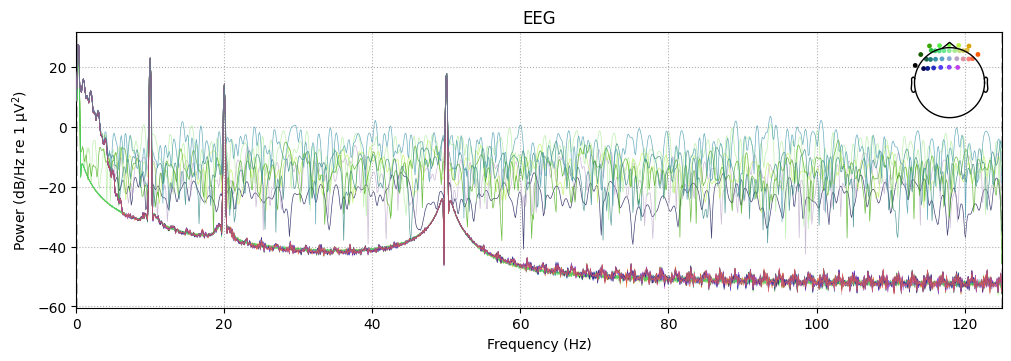

In [19]:
data = np.zeros((n_eeg, n_samples))

for i, ch in enumerate(eeg_names):

    brain = 8e-6 * pink_noise(n_samples)

    # Posterior alpha dominance
    alpha_amp = 25e-6 if ch.startswith(("O", "PO")) else 8e-6
    alpha = alpha_amp * np.sin(2*np.pi*10*times)

    beta = 3e-6 * np.sin(2*np.pi*20*times)
    drift = 15e-6 * np.sin(2*np.pi*0.3*times)
    line = 5e-6 * np.sin(2*np.pi*50*times)

    data[i] = brain + alpha + beta + drift + line


# ---- Create synthetic EOG channel ----
eog_signal = np.zeros(n_samples)

for blink_time in np.random.randint(5, duration-5, size=5):
    idx = int(blink_time * sfreq)
    width = int(0.5 * sfreq)
    blink = 150e-6 * np.exp(-np.linspace(-2, 2, width)**2)
    eog_signal[idx:idx+width] += blink[:min(width, n_samples-idx)]

# Add blink leakage to frontal EEG
for i, ch in enumerate(eeg_names):
    if ch.startswith(("Fp", "F")):
        data[i] += 0.3 * eog_signal


# Muscle bursts
for _ in range(8):
    ch = np.random.randint(0, n_eeg)
    start = np.random.randint(0, n_samples-500)
    data[ch, start:start+500] += 20e-6 * np.random.randn(500)


# Stack EEG + EOG
data_all = np.vstack([data, eog_signal])

ch_names = eeg_names + ["EOG"]
ch_types = ["eeg"] * n_eeg + ["eog"]

info = mne.create_info(
    ch_names=ch_names,
    sfreq=sfreq,
    ch_types=ch_types
)

raw = mne.io.RawArray(data_all, info)
raw.set_montage(montage, on_missing="ignore")

raw.plot_psd()


Filtering raw data in 1 contiguous segment
Removed notch frequencies (Hz):
     50.00 :  352 windows
    100.00 :  352 windows
Line noise report:
{'name': 'iir_Q160.0_df+0.00', 'J': 0.7101691217737615, 'resid_db': 0.5915302179076206, 'shoulder_drop_pct': -15.527485512801809, 'band_change_pct': 0.0013314411384670313, 'stage': 'bestof', 'detected_f0': 50.0, 'prom_db': 80.28738918200301}
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


c:\coding-portfolio\EEG pipeline\src\venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


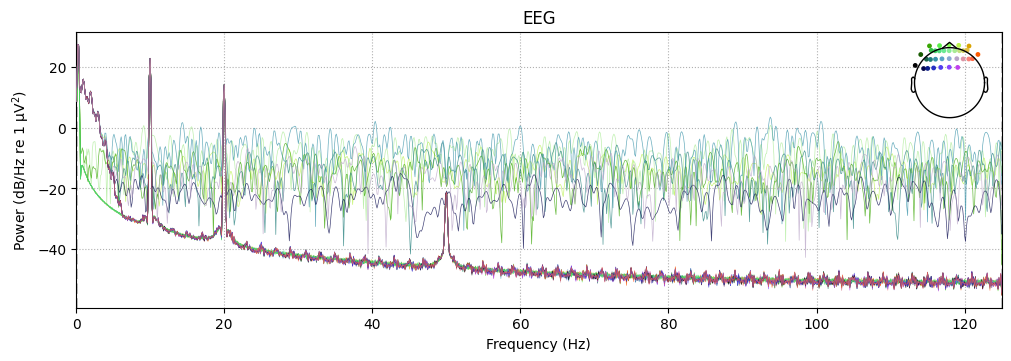

In [20]:
raw_ln, ln_report = line_noise_bestof_safe(raw)

print("Line noise report:")
print(ln_report)

raw_ln.plot_psd()


Recommended high-pass: 0.1
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


c:\coding-portfolio\EEG pipeline\src\venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


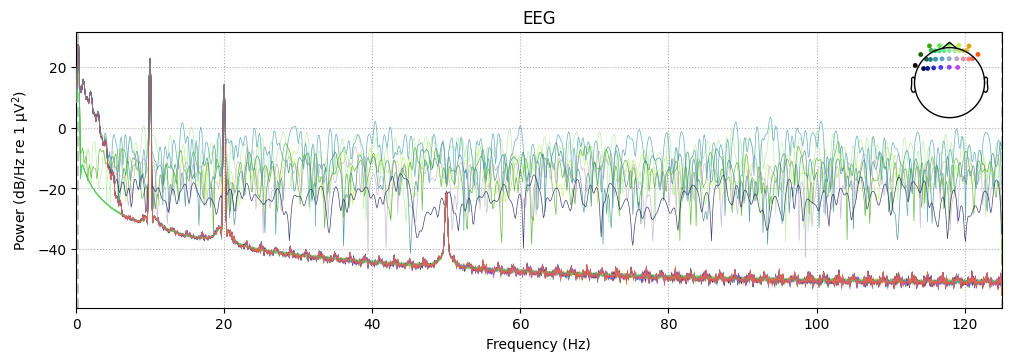

In [21]:
cfg = PipelineConfig()

raw_hp, hp_report = adaptive_highpass(
    raw_ln,
    candidates=cfg.highpass_candidates,
    drift_target=cfg.drift_target_pct,
    band_tol=cfg.band_tol_pct
)

print("Recommended high-pass:", hp_report["recommended"])

raw_hp.plot_psd()


Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 7.1s.


c:\coding-portfolio\EEG pipeline\src\venv\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
C:\Users\emili\AppData\Local\Temp\ipykernel_1636\2349554152.py:5: RuntimeWarning: Using n_components=15 (resulting in n_components_=15) may lead to an unstable mixing matrix estimation because the ratio between the largest (28) and smallest (5e-06) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 9
  ica.fit(raw_ica)


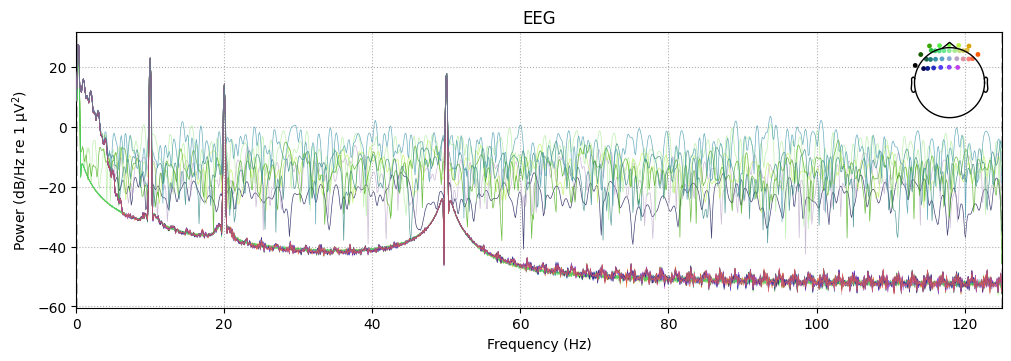

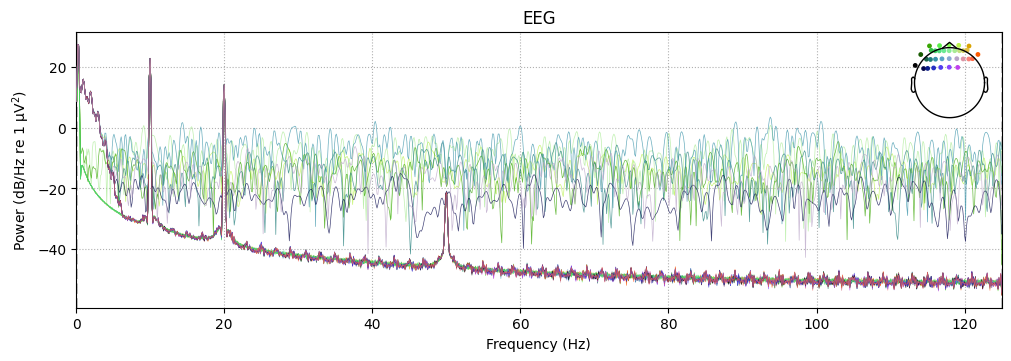

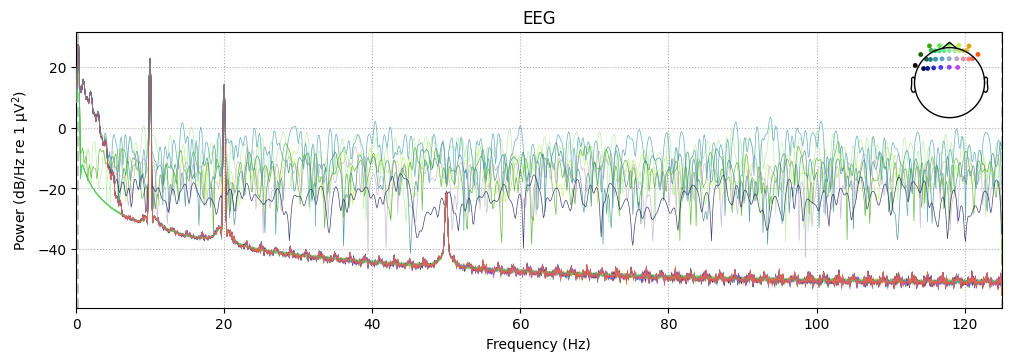

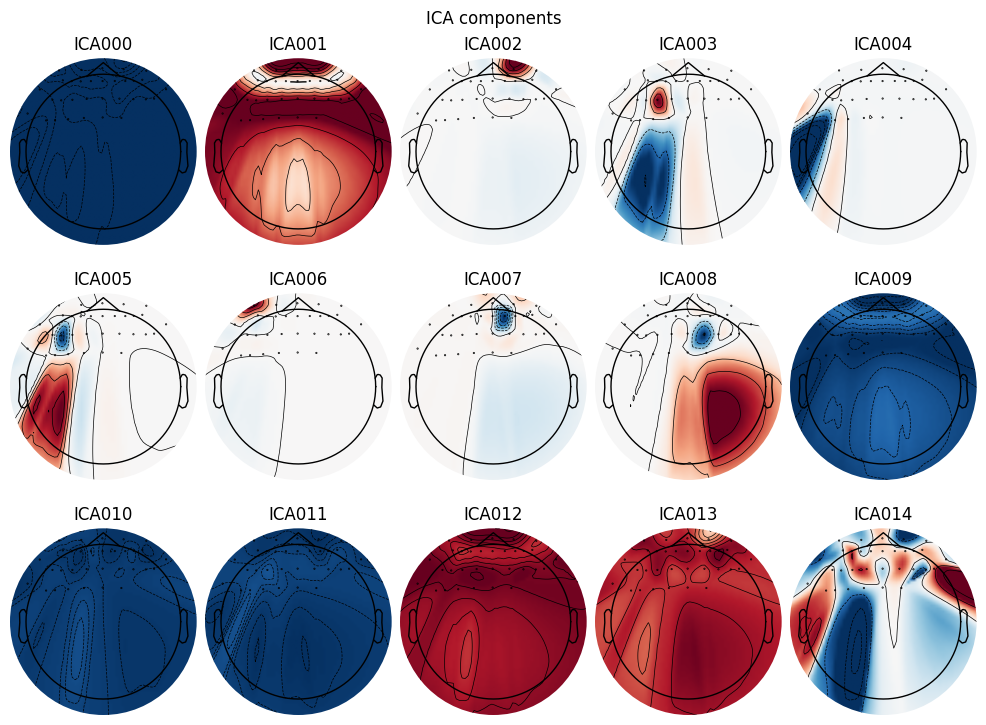

Using EOG channel: EOG
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- 

c:\coding-portfolio\EEG pipeline\src\venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


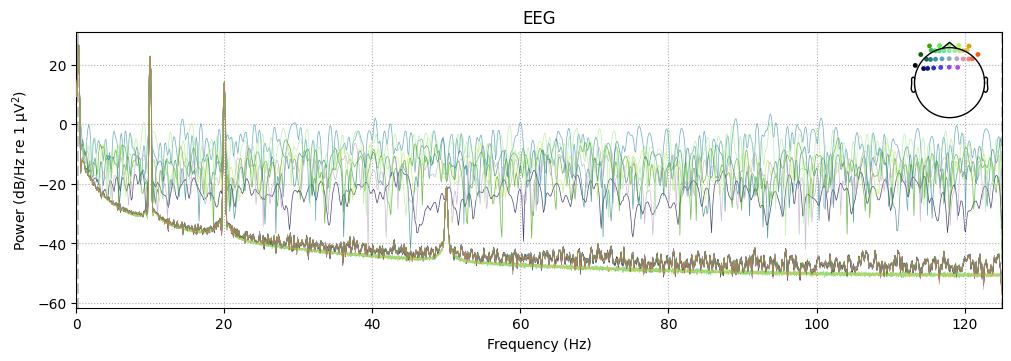

In [22]:
raw_ica = raw_hp.copy()
raw_ica.filter(1., None)

ica = mne.preprocessing.ICA(n_components=15, random_state=97)
ica.fit(raw_ica)

ica.plot_components()

eog_inds, scores = ica.find_bads_eog(raw_ica, ch_name="EOG")
print("Detected EOG components:", eog_inds)

ica.exclude = eog_inds

raw_clean = ica.apply(raw_hp.copy())

raw_clean.plot_psd()


In [23]:
try:
    from asrpy import ASR
    
    asr = ASR(sfreq=sfreq, cutoff=4)
    asr.fit(raw_clean)
    raw_asr = asr.transform(raw_clean.copy())

    print("ASR applied.")
    raw_asr.plot_psd()

except Exception as e:
    print("ASR not available:", e)
    raw_asr = raw_clean


c:\coding-portfolio\EEG pipeline\src\venv\Lib\site-packages\asrpy\asr_utils.py:107: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rows = np.arange(0, int(np.round(n * max_width)))
c:\coding-portfolio\EEG pipeline\src\venv\Lib\site-packages\asrpy\asr_utils.py:120: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gridsearch = np.round(n * np.arange(max_width, min_width, -step_sizes[1]))
c:\coding-portfolio\EEG pipeline\src\venv\Lib\site-packages\asrpy\asr_utils.py:120: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performi

ASR applied.
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


c:\coding-portfolio\EEG pipeline\src\venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


In [24]:
features = EEGFeatures(
    raw=raw_asr,
    per_channel=False,
    return_averages=True,
    qc=True
)

spectral_features = features.features_spectral()

print("\nExtracted spectral features (first 10):")
for k, v in list(spectral_features.items())[:10]:
    print(k, ":", v)

print("\nQC information:")
print(features._qc)


[INFO] EEGFeatures: [QC:spectral] 1.67s | channels=32 | NaN 0/160 (0.0%)
INFO:EEGFeatures:[QC:spectral] 1.67s | channels=32 | NaN 0/160 (0.0%)



Extracted spectral features (first 10):
spectral.abs_delta_avg : 1.2976001504898433e-12
spectral.abs_theta_avg : 4.737108002365679e-13
spectral.abs_alpha_avg : 1.474919252317946e-11
spectral.abs_beta_avg : 2.3201072440698533e-12
spectral.abs_gamma_avg : 1.3098215152720961e-13
spectral.rel_delta_avg : 0.033383598986305635
spectral.rel_theta_avg : 0.012187371139447
spectral.rel_alpha_avg : 0.37946482445617047
spectral.rel_beta_avg : 0.05969129285289792
spectral.rel_gamma_avg : 0.003369873213883056

QC information:
{'spectral': {'runtime_sec': 1.6735, 'n_channels': 32, 'nan_values': 0, 'n_values': 160, 'nan_rate_pct': 0.0}}
